(ch:linear-correlation)=
# 선형 상관관계

상관관계는 선형 상관관계와 비선형 상관관계로 나뉜다.
선형 상관관계는 하나의 데이터 값이 증가함에 따라 다른 데이터 값이 일차함수로 
단조증가(양의 상관관계) 또는 단조감소(음의 상관관계)를 의미한다.
반면에 비선형 상관관계는 일차함수보다 복잡한 함수로 나타나는 경우를 말한다.

2차원 데이터를 다루는 대부분의 경우, 선형 상관관계 여부를 분석하며, 이를 평가하기 위한 척도로서
공분산<font size='2'>covariance</font>과 상관계수<font size='2'>correlation coefficient</font>를 사용한다.

**기본 설정**

`numpy`와 `pandas` 라이브러리를 각각 `np`와 `pd`로 불러온다.

In [1]:
import numpy as np
import pandas as pd

데이터프레임의 [chained indexing을 금지시키기 위한 설정](https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy)을 지정한다.
Pandas 3.0 버전부터는 기본 옵션으로 지정된다.

In [2]:
pd.options.mode.copy_on_write = True

C:\Users\gslee\AppData\Local\Temp\ipykernel_38332\856138102.py:1: Pandas4Warning: The 'mode.copy_on_write' option is deprecated. Copy-on-Write can no longer be disabled (it is always enabled with pandas >= 3.0), and setting the option has no impact. This option will be removed in pandas 4.0.
  pd.options.mode.copy_on_write = True


주피터 노트북에서 부동소수점의 출력을 소수점 이하 6자리로 제한한다.
아래 코드는 주피터 노트북에서만 사용하며 일반적인 파이썬 코드가 아니다.

In [3]:
%precision 6

'%.6f'

아래 코드는 데이터프레임 내에서 부동소수점의 출력을 소수점 이하 6자리로 제한한다.

In [4]:
pd.set_option('display.precision', 6)

데이터 시각화를 위해 `matplotlib.pyplot`를 `plt`라는 별칭으로 불러온다.

In [5]:
import matplotlib.pyplot as plt

코드에 사용되는 [데이터 저장소의 기본 디렉토리](https://github.com/codingalzi/statsRev/tree/master/data)를 지정한다.

In [6]:
data_url = 'https://raw.githubusercontent.com/codingalzi/statsRev/refs/heads/master/data/'

## 삶의 만족도 데이터셋

**상관관계의 종류: 양, 음, 무상관**

두 변수 사이의 관계는 크게 세 가지로 나눌 수 있습니다:
1. **양의 상관관계**: 한 변수가 증가할 때 다른 변수도 증가하는 경향. (예: 운동 시간과 근육량)
2. **음의 상관관계**: 한 변수가 증가할 때 다른 변수가 감소하는 경향. (예: 자동차 무게와 연비)
3. **무상관 (상관관계 없음)**: 산점도가 뚜렷한 패턴 없이 퍼져 있어 직선 형태의 관계를 찾기 힘든 경우.

먼저 실습에 사용할 데이터 하나를 살펴본 후 상관관계를 다룬다.

OECD(경제협력개발기구)가 2011년부터 매년 발표하는 
[**더 나은 삶 지수**<font size='2'>Better Life Index(BLI)</font>](https://www.oecd.org/en/data/tools/oecd-better-life-index.html)는 
단순한 경제 성장 지표(GDP 등)를 넘어서,
국민의 삶의 질을 다각도로 평가하고 비교하기 위해 만들어진 지표다.

더 나은 삶 지수(BLI)는 삶의 질을 구성하는 11개 영역을 기준으로 OECD 회원국의 웰빙 수준을 측정한다.

| 항목 | 설명 |
|------|------|
| 소득 | 가처분 소득 수준 |
| 일자리 | 고용률, 일자리 안정성 |
| 주거 | 주거 환경과 비용 |
| 건강 | 기대수명, 건강 상태 |
| 교육 | 교육 수준 및 접근성 |
| 환경 | 대기질, 수질 등 |
| 공동체 | 사회적 연결과 신뢰 |
| 시민참여 | 정치적 참여와 민주적 권리 |
| 안전 | 범죄율, 생활 안전 |
| 삶의 만족도 | 주관적 행복도 |
| 일과 삶의 균형 | 여가 시간, 근로시간 등 |

여기서는 11개 지표 중에서 2015년도와 2024년도 OECD 36개 회원국가의 '삶의 만족도' 데이터를 활용한다.

In [24]:
life_satisfaction = pd.read_csv(data_url + "life_satisfaction_2015_2024.csv", index_col='Country')
life_satisfaction

,2015,2024
Country,,
Australia,7.3,7.1
Austria,6.9,7.2
Belgium,6.9,6.8
Brazil,7.0,6.1
Canada,7.3,7.0
Chile,6.7,6.2
Czech Republic,6.5,6.9
Denmark,7.5,7.5
Estonia,5.6,6.5


연도별로 각각 36개의 부동소수점이 포함되어 있음을 확인한다.

In [25]:
life_satisfaction.info()

<class 'pandas.DataFrame'>
Index: 36 entries, Australia to United States
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   2015    36 non-null     float64
 1   2024    36 non-null     float64
dtypes: float64(2)
memory usage: 1.1 KB


## 상관관계와 산점도

2015년도 국가별 삶의 만족도와 2024년도 국가별 삶의 만족도 사이의 상관관계 여부를 시각적으로 확인하기 위해
**산점도**<font size='2'>scatter plot</font>를 그려본다.
산점도는 `matplotlib.pyplot` 라이브러리에 포함된 `scatter()` 함수를 이용하여 그린다.

먼저 2015년 데이터와 2024년 데이터를 나눠 넘파이 어레이로 지정한다.

In [26]:
life_satisfaction_2015 = np.array(life_satisfaction['2015'])
life_satisfaction_2024 = np.array(life_satisfaction['2024'])

아래 코드에서 그리는 산점도는 x-축이 2015년도 국가별 삶의 만족도, y-축이 2024년도 국가별 삶의 만족도다.

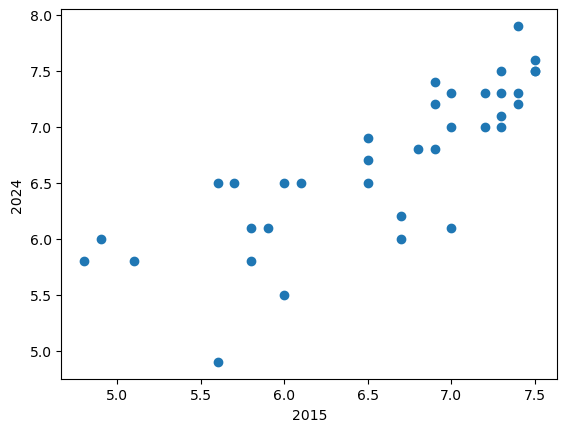

In [27]:
plt.scatter(life_satisfaction_2015, life_satisfaction_2024)

plt.xlabel('2015')
plt.ylabel('2024')

plt.show()

위 산점도는 2015년도 국가별 삶의 만족도가 높아질수록 2024년도 국가별 삶의 만족도도 올라가는 경향이 있음을 보여준다.
즉 두 데이터는 양의 선형 상관관계를 갖는다고 추측할 수 있다.

이제 선형 상관관계를 수치화한 두 가지 척도, 
**공분산**<font size='2'>covariance</font>과 
**상관계수**<font size='2'>correlation coefficient</font>를 통해 살펴보자. 
먼저 공분산을 소개한다.

## 공분산

이전 장에서
다룬 분산<font size='2'>variance</font>은 한 종류의 데이터 
$X=\{ x_1,\cdots, x_n \}$에 대해 샘플값들의 편차의 제곱의 평균값이다.
아래 식과 같이 계산되며, 샘플값들이 평균으로부터 떨어져있는 정도를 나타내는 양의 측정치이다.

$$
S_X^2 = \frac 1 n \sum_{i=1}^{n} (x_i - \bar x)^2 = \frac 1 n \left\{(x_1 - \bar x)^2 + (x_2 - \bar x)^2 + \cdots + (x_n - \bar x)^2 \right \}
$$


공분산<font size='2'>covariance</font>은 두 종류의 데이터 $X=\{ x_1, \cdots, x_n \}$와 $Y=\{ y_1,
\cdots, y_n \}$에 대해 다음과 같이 정의하며 $S_{XY}$로 표기하자.

$$
\begin{align*}
S_{XY} & = \frac 1 n \sum_{i=1}^{n} (x_i - \bar x)(y_i - \bar y) \\
&= \frac 1 n \left\{ (x_1 - \bar x)(y_1 - \bar y) + (x_2 - \bar x)(y_2 - \bar y) + \cdots + (x_n - \bar x)(y_n - \bar y) \right\}
\end{align*}
$$

위의 두 식으로부터 알 수 있는 사실은, 분산과 달리 공분산은 음수가 나올 수 있다는 것이다.
분산은 한 종류의 데이터에 대해 편차의 제곱의 평균이므로 항상 양의 값을 갖는다. 하지만 공분산은 두 종류의 데이터에 대해 편차의 곱의 평균인데, 곱해지는 편차의 부호가 다른 항들은 음수가 되므로 평균 또한 음수가 될 수 있다.

넘파이와 판다스 모두 공분산을 계산하는 API를 제공하는데, 넘파이의 `cov()` 함수와 데이터프레임의 `cov()` 메서드가 그것이다.

**넘파이의 `cov()` 함수**

아래 코드는 넘파이의 `cov()` 함수를 이용해 두 데이터의 공분산을 계산한다. (2, 2) 행렬 모양의 어레이가 생성되는데, 이 어레이의 항목별 의미는 다음과 같다.

| 인덱스 | 의미 |
| :---: | :--- |
| `[0, 0]` | 2015년도 삶의 만족도의 분산 |
| `[0, 1]` | 2015년도 삶의 만족도와 2024년도 삶의 만족도의 공분산 |
| `[1, 0]` | 2024년도 삶의 만족도와 2015년도 삶의 만족도의 공분산 |
| `[1, 1]` | 2024년도 삶의 만족도의 분산 |

In [28]:
cov_mat = np.cov(life_satisfaction_2015, life_satisfaction_2024, ddof=0)
cov_mat

array([[0.605278, 0.428009],
       [0.428009, 0.464159]])

공분산의 계산식으로부터 알 수 있듯이, '2015년도 국가별 삶의 만족도와 2024년도 국가별 삶의 만족도의 공분산'과
'2024년도 국가별 삶의 만족도와 2015년도 국가별 삶의 만족도의 공분산'은 동일하다. 
아래 두 코드는 각 연도별 공분산은 해당 연도의 표본분산과 일치하는지 확인해준다.

In [29]:
print("2015년도 국가별 삶의 만족도 분산:", np.var(life_satisfaction_2015, ddof=0))

2015년도 국가별 삶의 만족도 분산: 0.6052777777777778


In [30]:
print("2024년도 국가별 삶의 만족도분산:", np.var(life_satisfaction_2024, ddof=0))

2024년도 국가별 삶의 만족도분산: 0.46415895061728396


**데이터프레임의 `cov()` 메서드**

데이터프레임 객체의 `cov()` 메서드는 모든 특성들 사이의 공분산을 계산한다.
데이터프레임`life_satisfaction`에 `2015`와 `2024` 두 개의 특성이 있으므로, (2, 2) 행렬 모양의 데이터프레임을 생성한다.

앞서 `np.cov()`의 반환값을 설명할 때 사용된 인덱스가 여기서는 특성명으로 대체된다.

In [31]:
life_satisfaction.cov(ddof=0)

,2015,2024
2015,0.605278,0.428009
2024,0.428009,0.464159


**참고**

`ddof=1`로 지정하면 불편분산이 계산된다.

In [32]:
cov_mat = np.cov(life_satisfaction_2015, life_satisfaction_2024, ddof=1)
cov_mat

array([[0.622571, 0.440238],
       [0.440238, 0.477421]])

In [33]:
life_satisfaction.cov(ddof=1)

,2015,2024
2015,0.622571,0.440238
2024,0.440238,0.477421


**데이터 척도 변환과 공분산의 제약**

위에서 언급한 공분산의 최대 약점은 관측 데이터의 **단위 및 척도(Scale)**에 값이 크게 영향을 받는다는 점입니다. 이를 확인하기 위해, 단순히 2015년과 2024년의 만족도 점수에 임의로 100을 곱하여(단위 변경 시뮬레이션) 공분산을 다시 계산해봅시다.

In [34]:
scaled_2015 = life_satisfaction_2015 * 100
scaled_2024 = life_satisfaction_2024 * 100

np.cov(scaled_2015, scaled_2024, ddof=0)


array([[6052.777778, 4280.092593],
       [4280.092593, 4641.589506]])

단위가 100배 커지면서 분산과 편차의 곱절에 의해 수치 자체가 비상식적으로 크게 폭증하는 것을 볼 수 있습니다. 즉, 공분산의 절댓값 자체로는 관계의 강도를 신뢰성 있게 평가하기 어렵다는 한계가 직관적으로 증명됩니다.

## 상관계수

공분산은 데이터의 크기와 단위에 따라 계산된 값의 크기와 단위가 달라진다.
예를 들어 학생들의 키와 체중을 대상으로 공분산을 계산한다면 단위가 `cm * kg`이 되고,
멀리뛰기와 오래 매달리기의 공분산은 단위가 `m * sec`이 된다.
또한, 동일한 단위를 사용한다 하더라도 데이터 값의 척도(scale)에 따라 공분산 값도 많이 달라질 수 있다.

따라서 공분산 값의 절대적 크기는 선형 상관관계의 강도를 측정하는 기준이 될 수 없다. 이 점을 보완한 척도가 **상관계수**<font size='2'>correlation coefficient</font>이다. 여러가지 상관계수가 있으나, 가장 대표적인 것이 **피어슨 상관계수**<font size='2'>Pearson correlation coefficient</font>이다. 데이터 $X$와 $Y$의 피어슨 상관계수 $r_{XY}$는 공분산 $S_{XY}$을 각 데이터의 표준편차 $S_X$와 $S_Y$로 나눈 값이다. 아래 계산식으로부터 알 수 있듯이, 두 데이터의 단위 및 척도(scale)와 무관한, 항상 -1과 1 사이의 값이 나온다.

$$
r_{xy} = \frac{S_{xy}}{S_x \cdot S_y}
$$

피어슨 상관계수의 값으로부터 두 데이터의 상관관계는 다음과 같이 평가된다.

| 상관계수 | 의미 |
| :--- | :--- |
| 1에 가까운 값 | 양의 상관관계가 강함 |
| -1에 가까운 값 | 음의 상관관계가 강함 |
| 0에 가까운 값 | 상관관계가 거의 없음 |

아래 그림은 다양한 상관계수에 대응되는 산점도들이다.
상관계수의 절댓값이 1에 가까워질수록 산점도가 직선에 가까워지며,
0에 가까워질수록 산점도가 여러 방향으로 넓게 퍼져 두 데이터의 상관관계가 모호해진다.

<p><div align="center"><img src="https://github.com/codingalzi/statsRev/blob/master/jupyter-book/images/pearson_correlation.png?raw=true" style="width:700px"></div></p>

<p><div style="text-align: center">&lt;그림 출처: <a href="https://en.wikipedia.org/wiki/Pearson_correlation_coefficient">(Wikipedia) 피어슨 상관계수</a>&gt;</div></p>

**`np.corrcoef()` 함수**

상관계수는 넘파이의 `corrcoef()` 함수와 데이터프레임의 `corr()` 메서드로 계산할 수 있다.

넘파이 `corrcoef()` 함수의 반환값 모양과 항목별 의미는 공분산 `cov()` 함수의 경우와 동일하다.
2015년도 국가별 삶의 만족도와 2024년도 국가별 삶의 만족도의 상관계수는 0.81정도로,
두 데이터 사이의 선형 상관관계는 매우 크다고 평가할 수 있다.
즉, 2015년도의 삶의 만족도가 높을 수록 10여년 뒤의 삶의 만족도도 높은 경향이 강하다.

In [35]:
np.corrcoef(life_satisfaction_2015, life_satisfaction_2024)

array([[1.    , 0.8075],
       [0.8075, 1.    ]])

**데이터프레임의 `corr()` 메서드**

데이터프레임의 `corr()` 메서드도 동일한 결과를 보여준다.

In [36]:
life_satisfaction.corr()

,2015,2024
2015,1.0000,0.8075
2024,0.8075,1.0000


앞서 공분산의 약점(데이터의 단위 및 척도 문제)을 시연한 것과 동일하게, 이번에는 단위가 100배로 뻥튀기된(scaled) 변수들에 상관계수를 계산해 보겠습니다.

In [37]:
# 단위가 100배 커진 데이터를 활용 (이전 셀에서 `scaled_2015`, `scaled_2024`로 변환했음)
np.corrcoef(scaled_2015, scaled_2024)

array([[1.    , 0.8075],
       [0.8075, 1.    ]])

단위가 변경되더라도 상관계수 값은 일정합니다(`r ≈ 0.817`). 상관계수는 두 변수가 함께 변하는 정도를 측정하는 동시에 각 변수의 **단위 영향을 정규화(Standardization)**하기 때문에 관계의 척도 및 방향을 항상 -1 ~ 1 사이로 정량화할 수 있습니다.

---
## 상관관계 주의사항

데이터 분석 시 산점도를 무시하고 통계치(상관계수) 절댓값 하나만 맹신하거나 관계의 본질을 오해하는 경우가 빈번합니다. 여기서는 입문자가 흔히 범하는 대표적인 함정 두 가지를 살펴보겠습니다.

### 1. 상관관계 vs 인과관계 

> **상관관계 $\neq$ 인과관계 (Correlation does not imply causation)**

상관관계가 높다고 해서 반드시 두 변수 사이의 선행(원인)/후행(결과) **인과성**이 보장되는 것은 아닙니다. 제3의 변수가 두 변수 모두에 영향을 미치는 **허위 상관관계(Spurious Correlation)**일 수도 있습니다.

*   **예시:** "여름철 아이스크림 판매량"과 "상어의 인명 공격 횟수"가 양(+)의 강한 상관관계를 보였습니다. 아이스크림을 먹은 사람들이 상어에게 공격당할 확률이 높아질까요? 
    *   **진범(제3의 변수): 폭염(기온)**. 기온이 상승하니까 더위를 피해 해수욕장에 놀러 가는 사람이 많아졌고(상어 공격 증가), 동시에 더운 기온 때문에 아이스크림 판매도 덩달아 상승한 것입니다. 둘은 선형적인 동반 증가/감소의 패턴(상관관계)만 가질 뿐, 서로에게 직접적인 원인이 되는(아이스크림 $\rightarrow$ 상어) 인과관계는 없습니다.

### 2. 이상치(Outlier)의 영향과 앤스콤 콰르텟 (Anscombe's Quartet)

피어슨 상관계수($r$)는 특정 위치에 멀찍이 떨어진 한두 개의 **이상치**에 매우 극적으로 영향을 받을 수 있습니다. 따라서 데이터 분포를 요약한 대푯값(평균/분산/상관계수 등) 수치에만 완전히 기대는 것은 실무에서 큰 재앙을 야기합니다.

데이터의 시각적 분포가 얼마나 중요한가를 증명한 유명한 사례인 **앤스콤 콰르텟 (Anscombe's Quartet; 1973)** 데이터를 확인해 보겠습니다.

In [38]:
# 4개의 X, 4개의 Y로 이루어진 Anscombe 콰르텟 데이터
anscombe = pd.read_csv(data_url + "anscombe.csv")
anscombe.head()

,x1,x2,x3,x4,y1,y2,y3,y4
0,10,10,10,8,8.04,9.14,7.46,6.58
1,8,8,8,8,6.95,8.14,6.77,5.76
2,13,13,13,8,7.58,8.74,12.74,7.71
3,9,9,9,8,8.81,8.77,7.11,8.84
4,11,11,11,8,8.33,9.26,7.81,8.47


이 네 쌍의 `(x1, y1), (x2, y2), ... (x4, y4)` 변수들의 평균, 분산, 그리고 **상관계수**는 **모두 동일한 통계학적 수치**(`r ≈ 0.816`)를 반환합니다.

그렇다면 이들 쌍의 분포와 선형 상관성 형태는 똑같이 생겼을까요? 직접 시각화해 보겠습니다.

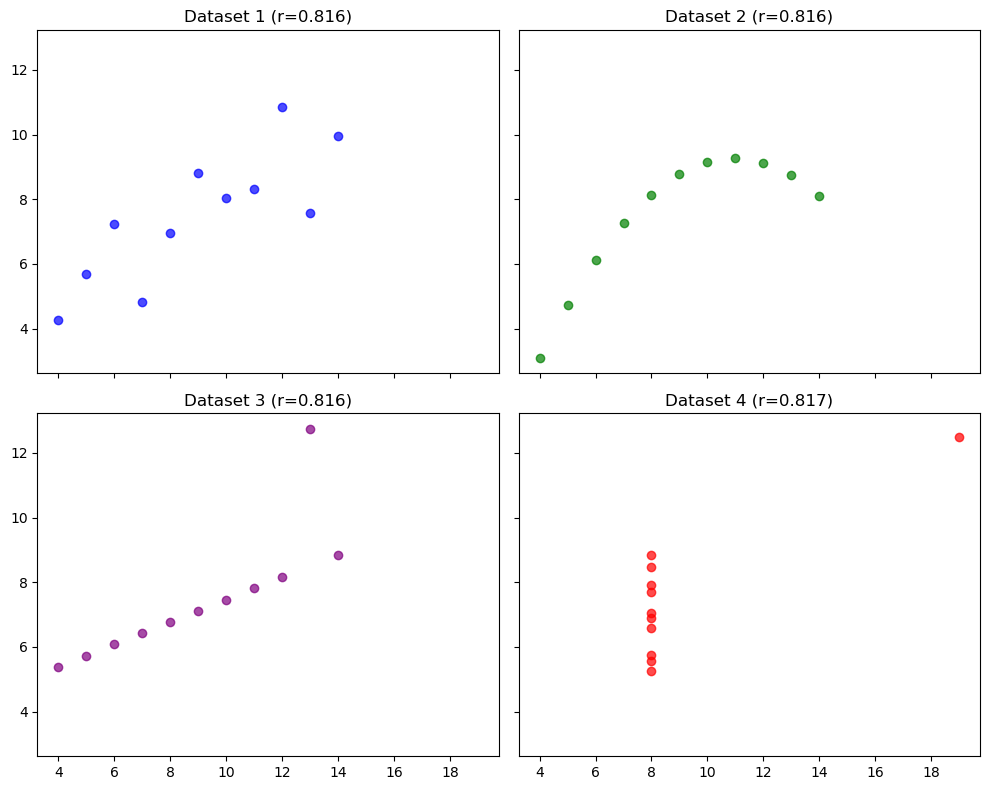

In [39]:
# 2행 2열 멀티 차트 서브플롯 준비
fig, ax = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)

# Dataset 1
ax[0, 0].scatter(anscombe['x1'], anscombe['y1'], color='blue', alpha=0.7)
ax[0, 0].set_title(f"Dataset 1 (r={anscombe['x1'].corr(anscombe['y1']):.3f})")

# Dataset 2
ax[0, 1].scatter(anscombe['x2'], anscombe['y2'], color='green', alpha=0.7)
ax[0, 1].set_title(f"Dataset 2 (r={anscombe['x2'].corr(anscombe['y2']):.3f})")

# Dataset 3
ax[1, 0].scatter(anscombe['x3'], anscombe['y3'], color='purple', alpha=0.7)
ax[1, 0].set_title(f"Dataset 3 (r={anscombe['x3'].corr(anscombe['y3']):.3f})")

# Dataset 4
ax[1, 1].scatter(anscombe['x4'], anscombe['y4'], color='red', alpha=0.7)
ax[1, 1].set_title(f"Dataset 4 (r={anscombe['x4'].corr(anscombe['y4']):.3f})")

plt.tight_layout()
plt.show()

놀랍게도 4개 데이터 쌍의 **피어슨 상관계수($r$)는 모두 0.816**으로 정확히 동일하며, 단순 선행 수치로만 보면 "서로 꽤 강한 양의 선형 상관관계"로 오판할 것입니다. 하지만 시각화 결과는 완전히 다릅니다.

- **데이터 1:** 기본적인 선형 상관관계의 모습.
- **데이터 2:** 비선형 상관관계(곡선 형태)이기 때문에 단순 피어슨 선형 상관계수로 요약하는 것은 부적절합니다.
- **데이터 3:** 완벽한 직선형이지만, 저 멀리 엇갈린 단 한 개의 **이상치(Outlier)**가 상관계수를 무너뜨리고 있습니다.
- **데이터 4:** X 변인은 통제되어 변화가 없는데(수직 방향), 하나의 악성 이상치가 피어슨 상관계수를 $r=0.816$의 완전히 왜곡된 양수로 만들었습니다.

**결론:** 수백 줄의 데이터를 단 하나의 통계치(상관계수) 평균 하나로 축소하는 것은 위험합니다. 항상 **산점도와 다변량 분포**를 시각적으로 관찰해야 합니다. 이를 위해 주로 실무에서는 Pandas `.corr()`과 시각화 라이브러리를 결합해 사용합니다.

### 상관관계 히트맵 (Heatmap) 예시

전체의 열람을 위해 Pandas 객체의 여러 특성들 사이의 피어슨 `corr()` 수치를 표 형태의 테이블로 나열하기보단, 행렬의 상관계수 강도(`-1` ~ `+1`)에 색상을 입혀 직관적인 데이터 분석 도면으로 볼 때 주로 `seaborn` 라이브러리의 `sns.heatmap()`을 씁니다.

다음 데이터셋에서 각기 상관계수의 절반 행렬만 표시하는 코드로 마무리합니다.

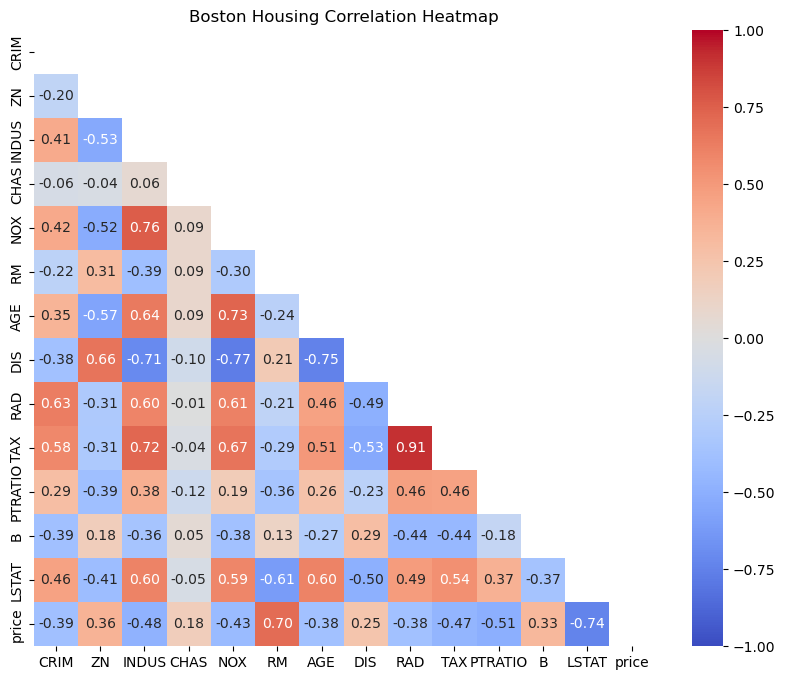

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# 실습을 위한 보스턴 주택 가격 데이터셋 활용
cols = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'price']
boston = pd.read_csv(data_url + "boston_housing.csv", sep=r"\s+", header=None, names=cols)

# 1. 14개 특성들간의 피어슨 상관계수 행렬 df 도출
corr_matrix = boston.corr(method='pearson')

# 2. 대칭되는 상관계수 우측 상단은 어둡게/중복 제거(마스킹)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
# 3. heatmap (coolwarm 컬러맵: 음(-1) = 파란색, 영(0) = 하얀색, 양(+1) = 빨간색)
sns.heatmap(corr_matrix, 
            mask=mask, 
            cmap='coolwarm', 
            annot=True,         # 상관계수 숫자 표시
            fmt=".2f",          # 소수점 2자리 제한
            vmin=-1, vmax=1)    # 최솟값, 최댓값 고정

plt.title('Boston Housing Correlation Heatmap')
plt.show()

위 히트맵에서 다음과 같은 정보를 한눈에 분석할 수 있습니다.

- 양의 강한 상관관계(빨간색): 방 개수(`RM`)와 집값(`price`); 상관계수 0.70
- 음의 강한 상관관계(파란색): 빈곤층 비율(`LSTAT`)이 늘수록 집값 감소(`price`); 상관계수 -0.74 등
- 자기 자신의 특성끼리는 항상 1입니다. (우상향 빗금선)

## 연습문제

참고: [(연습) 2차원 데이터](https://colab.research.google.com/github/codingalzi/statsRev/blob/master/practices/practice-twoD_data.ipynb)